In [122]:
# ============================================================================
# CTAB-GAN with Differential Privacy, KL/JS Divergence, and Bug Fixes
# ============================================================================

import os, math, numpy as np, pandas as pd
import torch, torch.nn as nn
from torch.nn.utils import spectral_norm, clip_grad_norm_
from sklearn.preprocessing import OneHotEncoder, QuantileTransformer, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from dataclasses import dataclass
from typing import Optional, Callable
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp, chi2_contingency, entropy
from scipy.spatial.distance import jensenshannon
import warnings
warnings.filterwarnings('ignore')

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cuda


In [123]:
df=pd.read_csv("Datasets/default.csv")
df.replace('?', np.nan, inplace=True)
df.dropna(inplace=True)
syn_df=pd.read_csv("Results5/synthetic_lsf0.25.csv")
syn_df = syn_df.rename(columns={"sex": "gender"})
for col in syn_df.select_dtypes(include='object').columns:
    syn_df[col] = syn_df[col].str.strip()
syn_df.replace('?', np.nan, inplace=True)
syn_df.dropna(inplace=True)
syn_df = syn_df[df.columns]

In [124]:
# label_col = "income"  
# num_cols=['age', 'fnlwgt', 'educational-num', 'capital-gain', 'capital-loss','hours-per-week']
# cat_cols=['workclass', 'education', 'marital-status', 'occupation','relationship', 'race', 'gender', 'native-country', 'income']

In [125]:
# out_dir="Results"
# os.makedirs(out_dir, exist_ok=True)

In [126]:
label_col = "default"  
cat_cols = ["SEX", "EDUCATION", "MARRIAGE", "PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]
num_cols = list([col for col in df.columns if col not in cat_cols])


Plotting distribution comparisons...


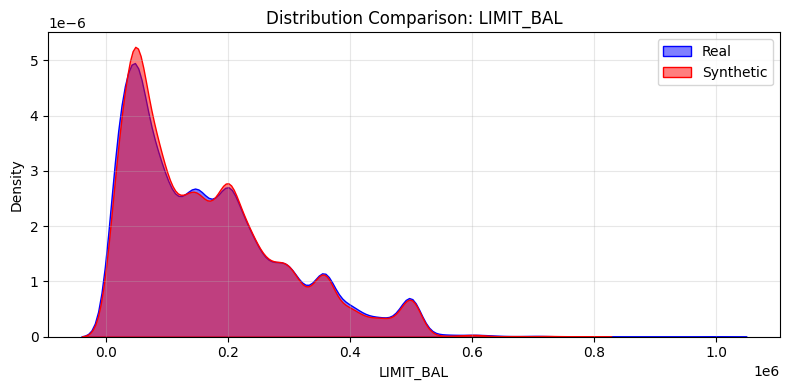

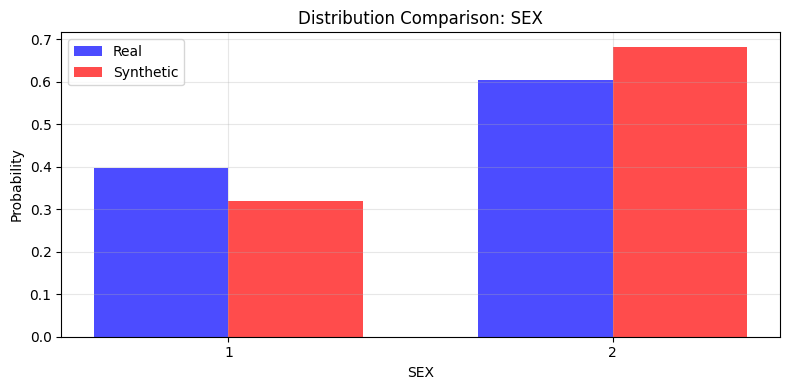

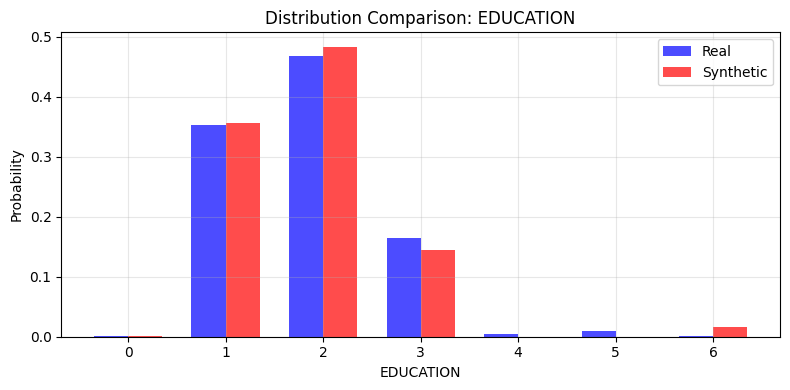

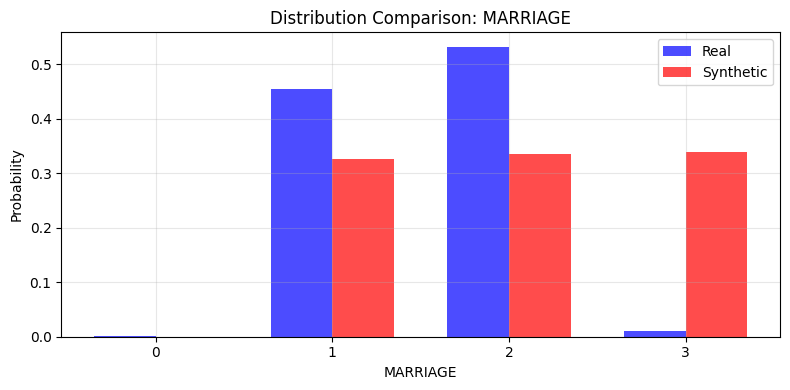

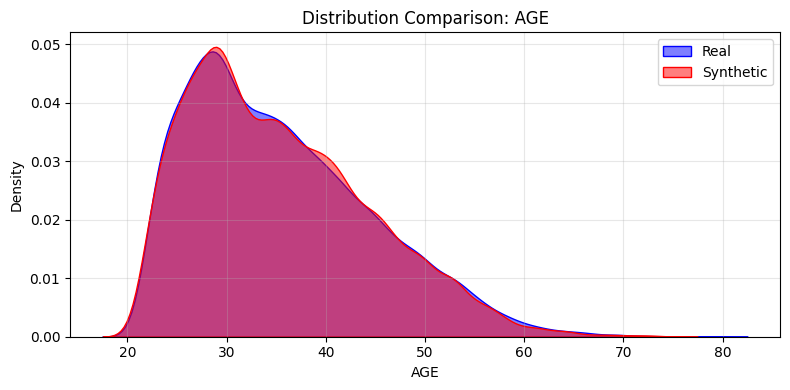

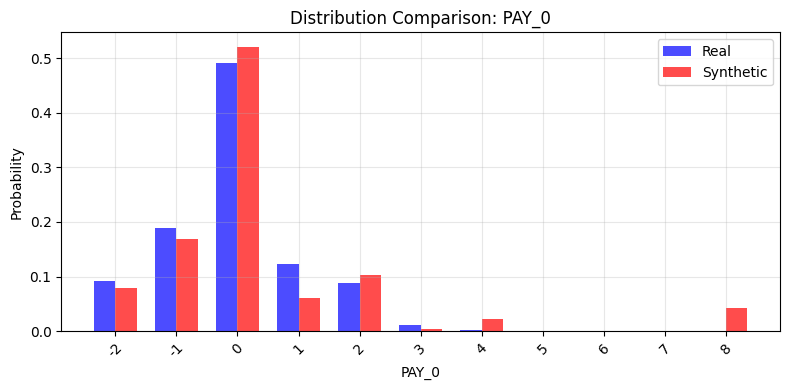

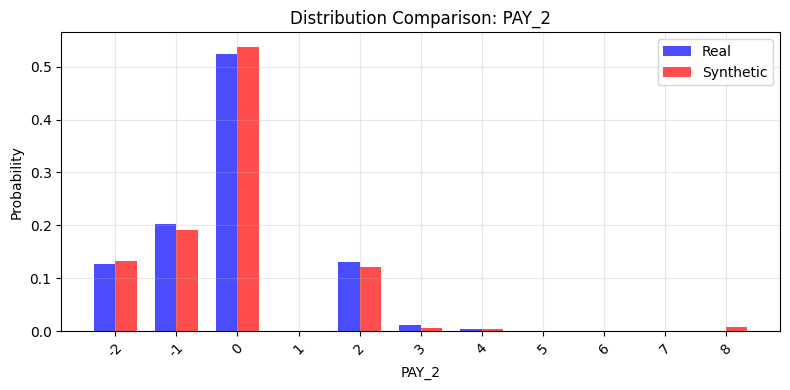

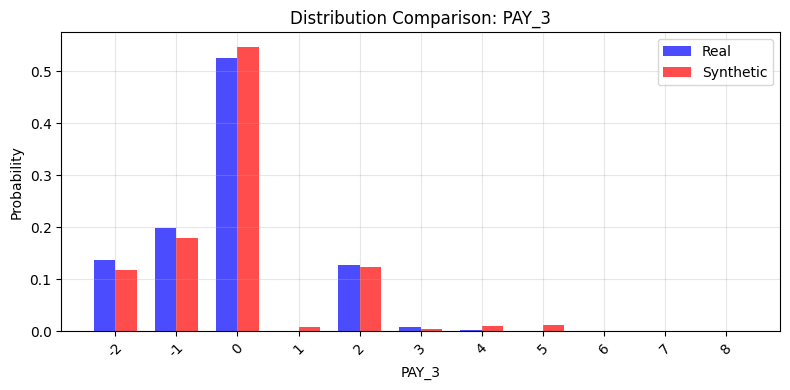

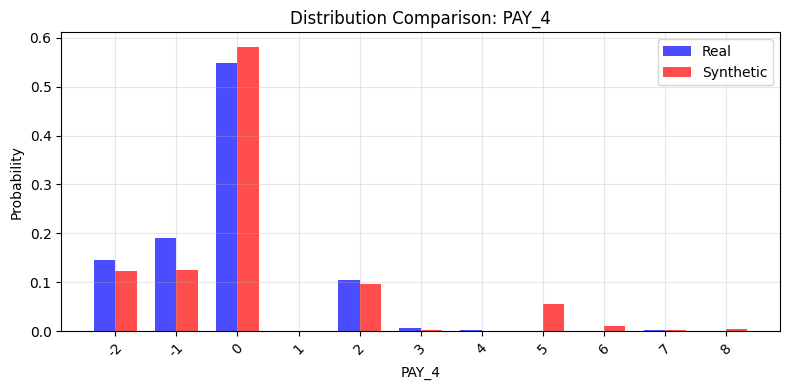

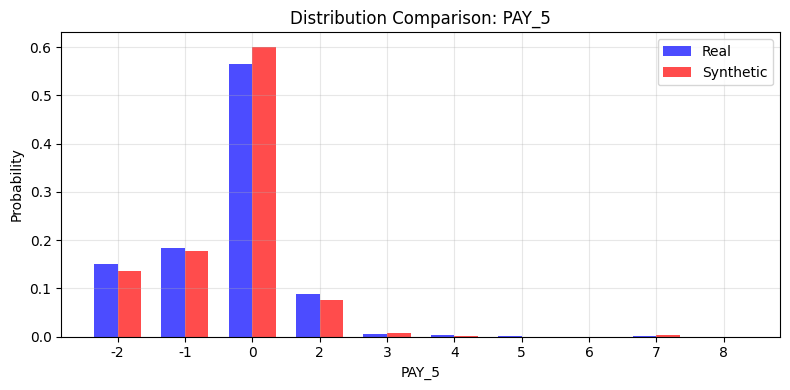

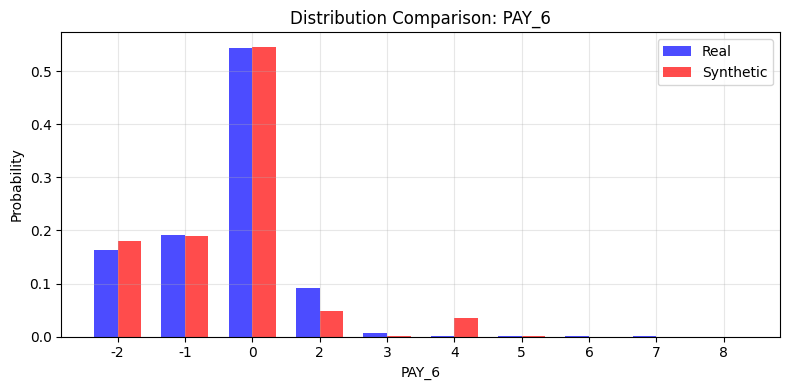

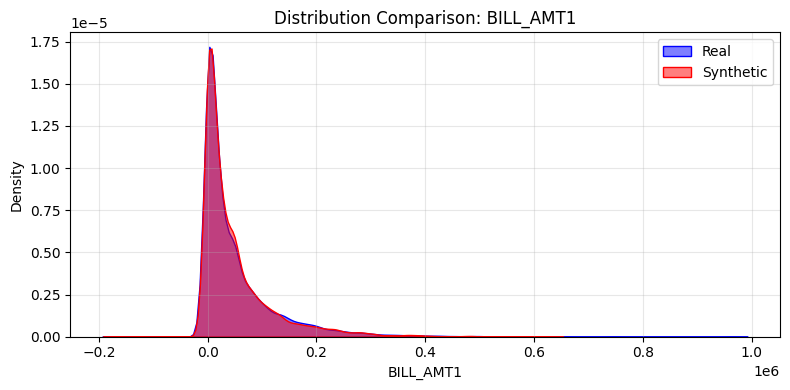

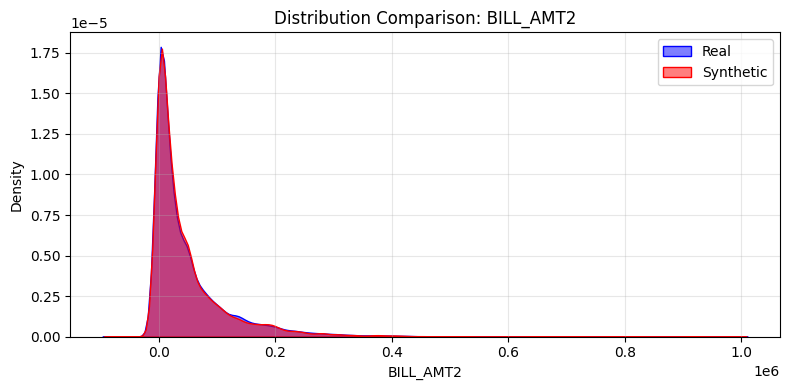

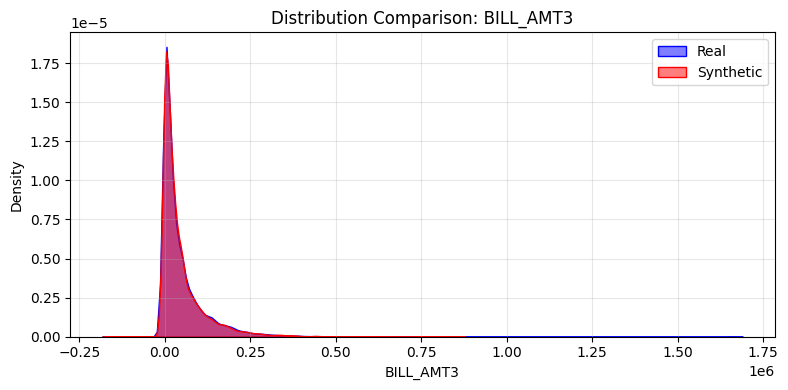

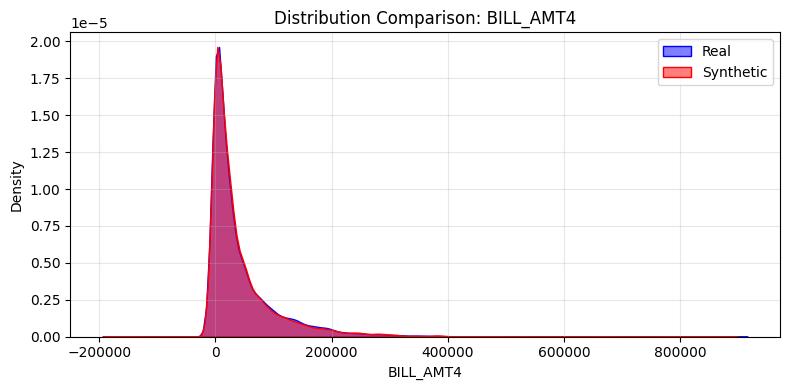

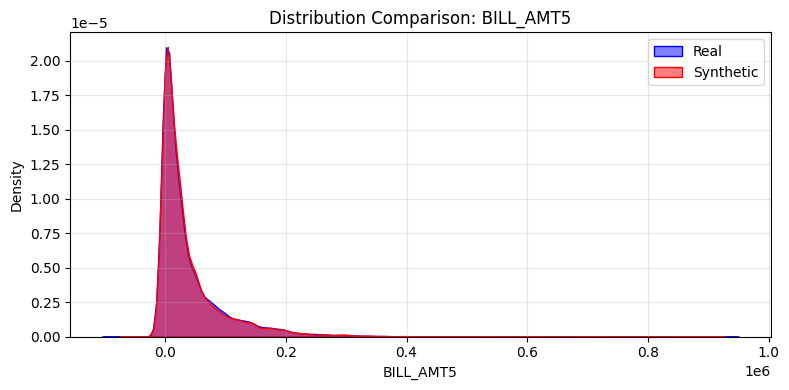

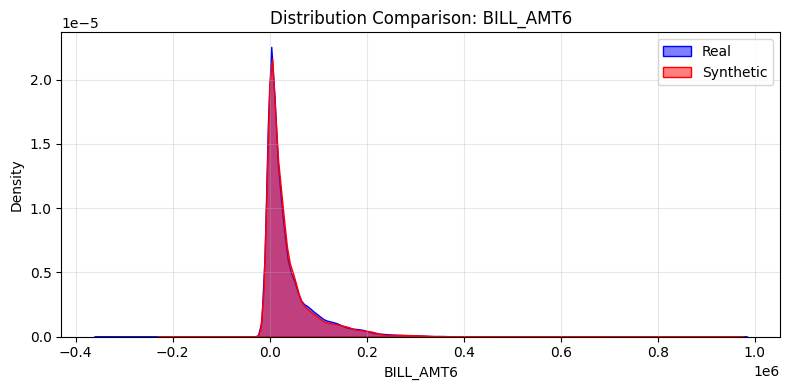

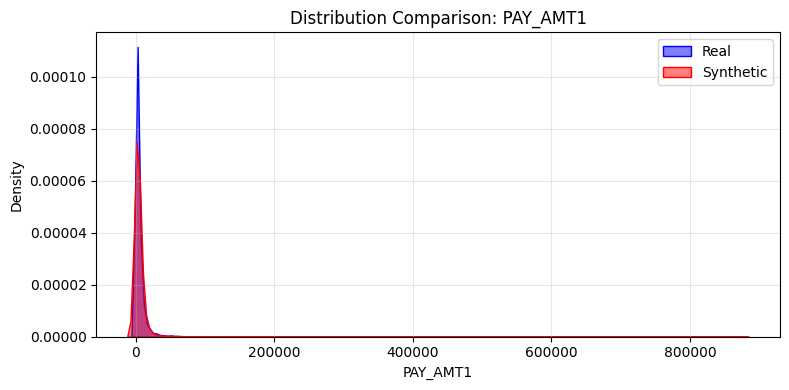

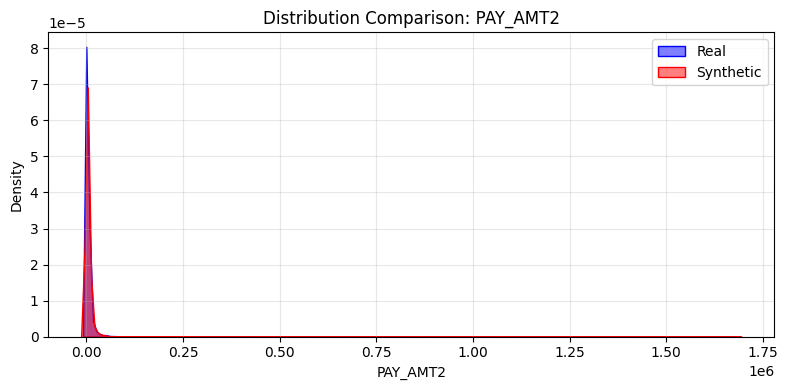

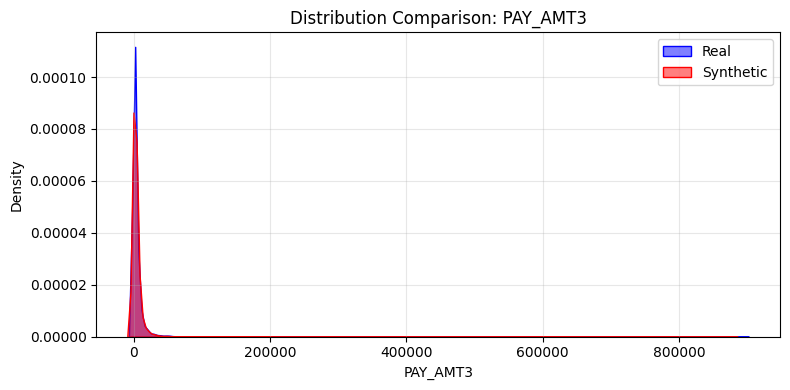

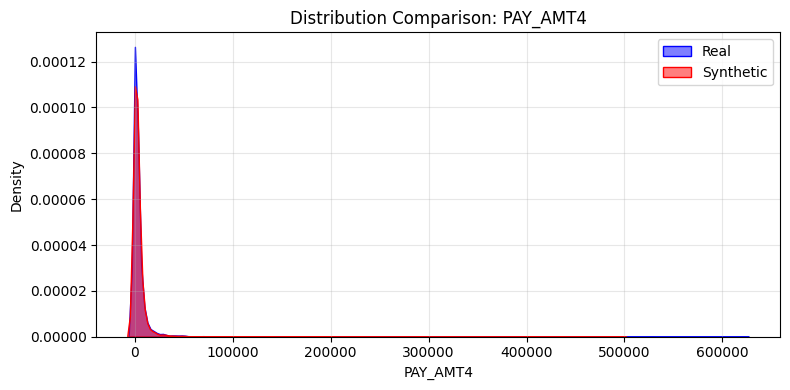

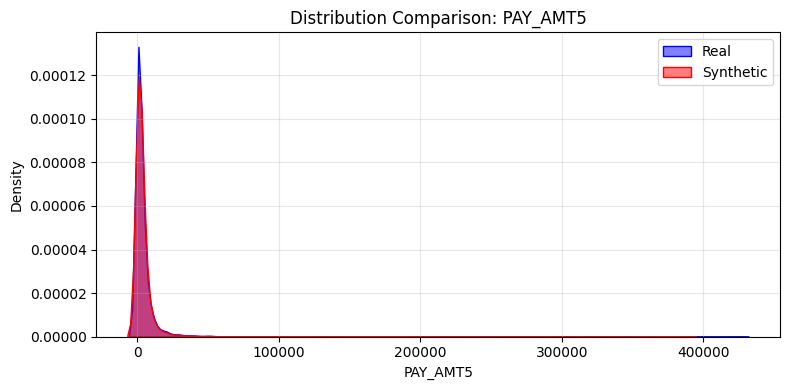

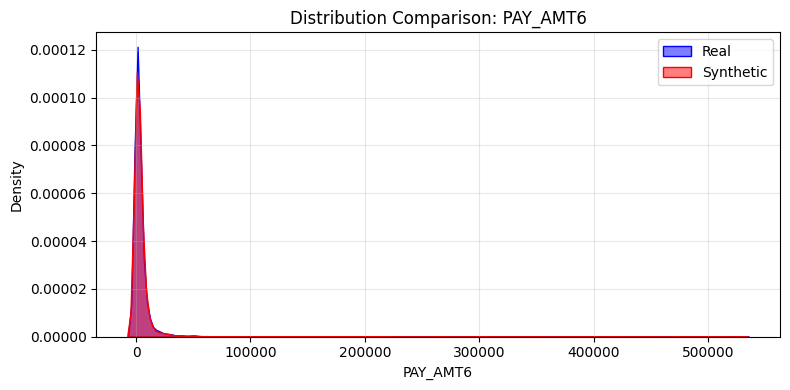

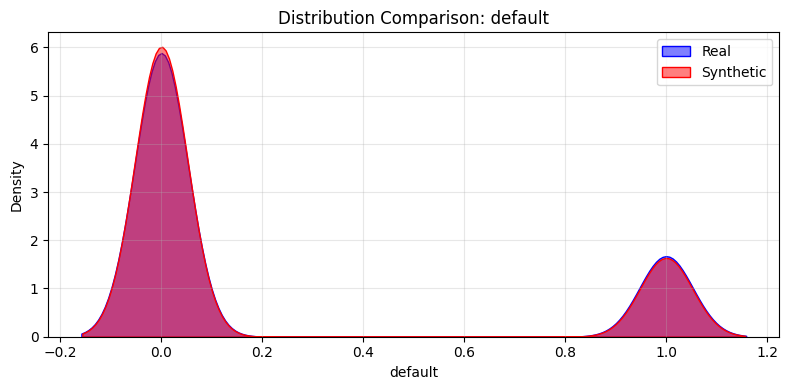

✅ Distribution plots completed


In [127]:
print("\nPlotting distribution comparisons...")
for col in df.columns:  
    plt.figure(figsize=(8, 4))
    
    if col in num_cols:
        # Numeric column - use KDE
        sns.kdeplot(df[col], label='Real', fill=True, alpha=0.5, color='blue')
        sns.kdeplot(syn_df[col], label='Synthetic', fill=True, alpha=0.5, color='red')
    else:
        # Categorical column - use bar plot
        real_counts = df[col].value_counts(normalize=True)
        syn_counts = syn_df[col].value_counts(normalize=True)
        
        # ✨ FIX: Align categories
        all_categories = sorted(set(real_counts.index) | set(syn_counts.index))
        real_counts = real_counts.reindex(all_categories, fill_value=0)
        syn_counts = syn_counts.reindex(all_categories, fill_value=0)
        
        x = np.arange(len(all_categories))
        width = 0.35
        
        plt.bar(x - width/2, real_counts.values, width, label='Real', alpha=0.7, color='blue')
        plt.bar(x + width/2, syn_counts.values, width, label='Synthetic', alpha=0.7, color='red')
        
        # Smart tick labeling
        if len(all_categories) <= 20:
            plt.xticks(x, all_categories, rotation=45 if len(all_categories) > 10 else 0)
        else:
            step = max(1, len(all_categories) // 10)
            plt.xticks(x[::step], [all_categories[i] for i in range(0, len(all_categories), step)], rotation=45)
    
    plt.title(f'Distribution Comparison: {col}')
    plt.xlabel(col)
    plt.ylabel('Density' if col in num_cols else 'Probability')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    #plt.savefig(os.path.join(out_dir, f'dist_comparison_{col}.png'), dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

print("✅ Distribution plots completed")

In [128]:
# ============================================================================
# 12. EVALUATION METRICS: KL and JS Divergence
# ============================================================================

def compute_histogram_probs(data, bins=50, range_vals=None):
    """Compute histogram probabilities for divergence calculation"""
    if range_vals is None:
        range_vals = (data.min(), data.max())
    
    hist, _ = np.histogram(data, bins=bins, range=range_vals, density=True)
    # Normalize to get probabilities
    hist = hist + 1e-10  # Add small constant to avoid log(0)
    hist = hist / hist.sum()
    return hist

def kl_divergence(real_data, syn_data, bins=50):
    """
    Compute KL Divergence: KL(P || Q) where P is real, Q is synthetic
    KL(P || Q) = sum(P(i) * log(P(i) / Q(i)))
    """
    # Get common range
    min_val = min(real_data.min(), syn_data.min())
    max_val = max(real_data.max(), syn_data.max())
    range_vals = (min_val, max_val)
    
    # Compute histograms
    p = compute_histogram_probs(real_data, bins=bins, range_vals=range_vals)
    q = compute_histogram_probs(syn_data, bins=bins, range_vals=range_vals)
    
    # Compute KL divergence
    kl = entropy(p, q)
    return kl

def js_divergence(real_data, syn_data, bins=50):
    """
    Compute JS Divergence: JS(P || Q)
    JS is symmetric and bounded [0, 1] (in bits) or [0, ln(2)] (in nats)
    """
    # Get common range
    min_val = min(real_data.min(), syn_data.min())
    max_val = max(real_data.max(), syn_data.max())
    range_vals = (min_val, max_val)
    
    # Compute histograms
    p = compute_histogram_probs(real_data, bins=bins, range_vals=range_vals)
    q = compute_histogram_probs(syn_data, bins=bins, range_vals=range_vals)
    
    # Compute JS divergence
    js = jensenshannon(p, q, base=2)  # base=2 for bits
    return js

def compute_divergences_for_dataframes(df_real, df_syn, num_cols, cat_cols, bins=50):
    """
    Compute KL and JS divergences for all columns
    """
    results = {
        'column': [],
        'type': [],
        'kl_divergence': [],
        'js_divergence': []
    }
    
    # Numeric columns
    for col in num_cols:
        real_vals = df_real[col].values
        syn_vals = df_syn[col].values
        
        kl = kl_divergence(real_vals, syn_vals, bins=bins)
        js = js_divergence(real_vals, syn_vals, bins=bins)
        
        results['column'].append(col)
        results['type'].append('numeric')
        results['kl_divergence'].append(kl)
        results['js_divergence'].append(js)
    
    # Categorical columns
    for col in cat_cols:
        # Get value counts
        real_counts = df_real[col].value_counts(sort=False)
        syn_counts = df_syn[col].value_counts(sort=False)
        
        # Align categories
        all_cats = sorted(set(real_counts.index) | set(syn_counts.index))
        p = np.array([real_counts.get(c, 0) for c in all_cats]) + 1e-10
        q = np.array([syn_counts.get(c, 0) for c in all_cats]) + 1e-10
        
        # Normalize
        p = p / p.sum()
        q = q / q.sum()
        
        # Compute divergences
        kl = entropy(p, q)
        js = jensenshannon(p, q, base=2)
        
        results['column'].append(col)
        results['type'].append('categorical')
        results['kl_divergence'].append(kl)
        results['js_divergence'].append(js)
    
    return pd.DataFrame(results)


EVALUATION: STATISTICAL TESTS

Kolmogorov-Smirnov Test (Numeric Columns):
------------------------------------------------------------
LIMIT_BAL           : KS statistic = 0.0182, p-value = 0.000095
AGE                 : KS statistic = 0.0061, p-value = 0.636655
BILL_AMT1           : KS statistic = 0.0210, p-value = 0.000003
BILL_AMT2           : KS statistic = 0.0208, p-value = 0.000005
BILL_AMT3           : KS statistic = 0.0194, p-value = 0.000024
BILL_AMT4           : KS statistic = 0.0161, p-value = 0.000830
BILL_AMT5           : KS statistic = 0.0205, p-value = 0.000007
BILL_AMT6           : KS statistic = 0.0229, p-value = 0.000000
PAY_AMT1            : KS statistic = 0.0459, p-value = 0.000000
PAY_AMT2            : KS statistic = 0.0382, p-value = 0.000000
PAY_AMT3            : KS statistic = 0.0394, p-value = 0.000000
PAY_AMT4            : KS statistic = 0.0392, p-value = 0.000000
PAY_AMT5            : KS statistic = 0.0423, p-value = 0.000000
PAY_AMT6            : KS statist

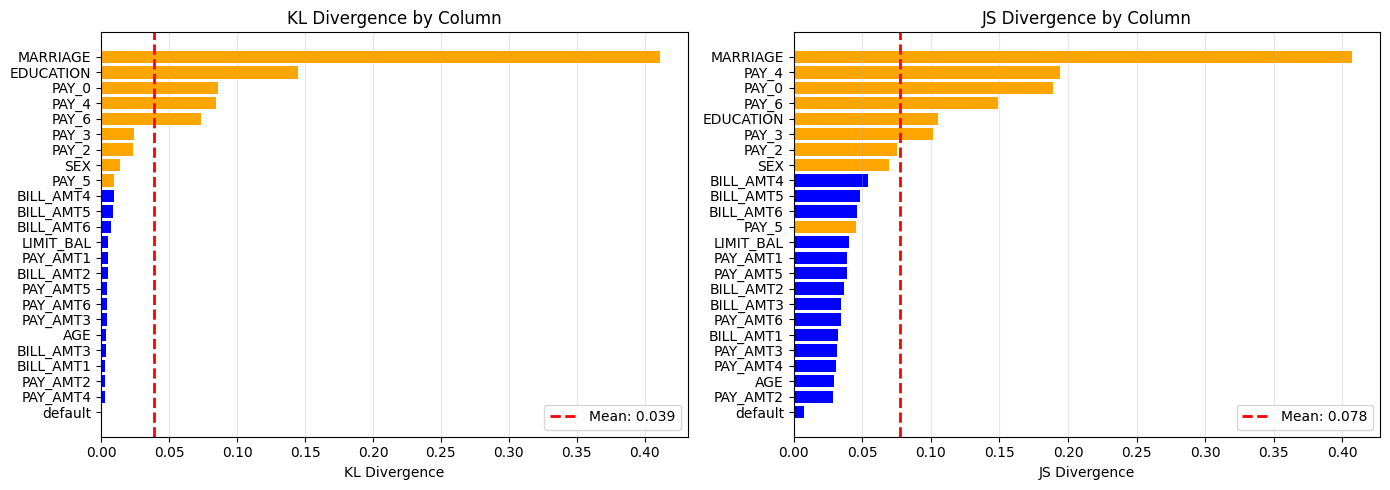

In [129]:
# ============================================================================
# 17. EVALUATION: STATISTICAL TESTS
# ============================================================================

print("\n" + "="*80)
print("EVALUATION: STATISTICAL TESTS")
print("="*80 + "\n")

# Kolmogorov-Smirnov test for numeric columns
print("Kolmogorov-Smirnov Test (Numeric Columns):")
print("-" * 60)
for col in num_cols:
    ks_stat, p_value = ks_2samp(df[col], syn_df[col])
    print(f"{col:20s}: KS statistic = {ks_stat:.4f}, p-value = {p_value:.6f}")

print("\n" + "-" * 60 + "\n")

# Chi-squared test for categorical columns
print("Chi-Squared Test (Categorical Columns):")
print("-" * 60)
for col in cat_cols:
    real_counts = df[col].value_counts()
    synth_counts = syn_df[col].value_counts()
    table = pd.concat([real_counts, synth_counts], axis=1).fillna(0)
    chi2, p, dof, expected = chi2_contingency(table.T)
    print(f"{col:20s}: χ² = {chi2:.4f}, p-value = {p:.6f}")

# ============================================================================
# 18. EVALUATION: KL AND JS DIVERGENCE
# ============================================================================

print("\n" + "="*80)
print("EVALUATION: KL AND JS DIVERGENCE")
print("="*80 + "\n")

# Compute divergences
divergence_results = compute_divergences_for_dataframes(df, syn_df, num_cols, cat_cols, bins=50)

print("KL and JS Divergence for all columns:")
print("-" * 80)
print(divergence_results.to_string(index=False))

# Save results
#divergence_results.to_csv(os.path.join(out_dir, "divergence_results.csv"), index=False)

# Summary statistics
print("\n" + "-" * 80)
print("\nSummary Statistics:")
print(f"Average KL Divergence: {divergence_results['kl_divergence'].mean():.4f}")
print(f"Average JS Divergence: {divergence_results['js_divergence'].mean():.4f}")
print(f"\nMedian KL Divergence: {divergence_results['kl_divergence'].median():.4f}")
print(f"Median JS Divergence: {divergence_results['js_divergence'].median():.4f}")

# Visualize divergences
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# KL Divergence
divergence_results_sorted = divergence_results.sort_values('kl_divergence')
axes[0].barh(divergence_results_sorted['column'], divergence_results_sorted['kl_divergence'], 
             color=['blue' if t == 'numeric' else 'orange' for t in divergence_results_sorted['type']])
axes[0].set_xlabel('KL Divergence')
axes[0].set_title('KL Divergence by Column')
axes[0].grid(True, alpha=0.3, axis='x')
axes[0].axvline(divergence_results['kl_divergence'].mean(), color='red', linestyle='--', 
                linewidth=2, label=f'Mean: {divergence_results["kl_divergence"].mean():.3f}')
axes[0].legend()

# JS Divergence
divergence_results_sorted = divergence_results.sort_values('js_divergence')
axes[1].barh(divergence_results_sorted['column'], divergence_results_sorted['js_divergence'],
             color=['blue' if t == 'numeric' else 'orange' for t in divergence_results_sorted['type']])
axes[1].set_xlabel('JS Divergence')
axes[1].set_title('JS Divergence by Column')
axes[1].grid(True, alpha=0.3, axis='x')
axes[1].axvline(divergence_results['js_divergence'].mean(), color='red', linestyle='--',
                linewidth=2, label=f'Mean: {divergence_results["js_divergence"].mean():.3f}')
axes[1].legend()

plt.tight_layout()
#plt.savefig(os.path.join(out_dir, "divergence_comparison.png"), dpi=150, bbox_inches='tight')
plt.show()

In [130]:
# Cell 1: imports & helper functions
import json
import numpy as np
import pandas as pd
from itertools import combinations
from typing import List, Tuple, Dict

from scipy.stats import ks_2samp, pearsonr
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from tqdm import tqdm

from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

# ---------- small helpers ----------
def total_variation_distance_counts(real_counts: np.ndarray, synth_counts: np.ndarray) -> float:
    p = real_counts.astype(float) / (real_counts.sum() + 1e-12)
    q = synth_counts.astype(float) / (synth_counts.sum() + 1e-12)
    return float(np.abs(p - q).sum())

# ---------- column fidelity ----------
def column_fidelity(real_df: pd.DataFrame, synth_df: pd.DataFrame,
                    categorical_cols: List[str], numeric_cols: List[str]) -> Tuple[Dict, float]:
    per_col = {}
    for col in numeric_cols:
        a = real_df[col].dropna().values
        b = synth_df[col].dropna().values
        if len(a) == 0 or len(b) == 0:
            ks_stat = 1.0
        else:
            ks_stat = ks_2samp(a, b).statistic
        omega = 1.0 - float(ks_stat)
        per_col[col] = {"type": "numeric", "ks": float(ks_stat), "omega_col": float(omega)}

    for col in categorical_cols:
        a = real_df[col].astype(str).fillna("__nan__").values
        b = synth_df[col].astype(str).fillna("__nan__").values
        real_counts = pd.Series(a).value_counts().sort_index()
        synth_counts = pd.Series(b).value_counts().reindex(real_counts.index, fill_value=0)
        tvd = total_variation_distance_counts(real_counts.values, synth_counts.values)
        omega = 1.0 - 0.5 * float(tvd)
        per_col[col] = {"type": "categorical", "tvd": float(tvd), "omega_col": float(omega)}

    Omega_col = float(np.mean([v["omega_col"] for v in per_col.values()]))
    return per_col, Omega_col

# ---------- row fidelity ----------
def compute_pairwise_row_fidelity(real_df: pd.DataFrame, synth_df: pd.DataFrame,
                                  categorical_cols: List[str], numeric_cols: List[str]) -> Tuple[Dict, float]:
    per_pair = {}
    scores = []

    # numeric-numeric pairs
    for a, b in combinations(numeric_cols, 2):
        ra = real_df[a].dropna().values
        rb = real_df[b].dropna().values
        sa = synth_df[a].dropna().values
        sb = synth_df[b].dropna().values
        try:
            rho_real = float(pearsonr(ra, rb)[0])
        except Exception:
            rho_real = 0.0
        try:
            rho_synth = float(pearsonr(sa, sb)[0])
        except Exception:
            rho_synth = 0.0
        delta = abs(rho_real - rho_synth)
        omega = 1.0 - 0.5 * delta
        per_pair[(a,b)] = {"type": "num-num", "rho_real": rho_real, "rho_synth": rho_synth, "omega_row": float(omega)}
        scores.append(omega)

    # categorical-categorical pairs (joint TVD)
    for a, b in combinations(categorical_cols, 2):
        ra = real_df[[a,b]].astype(str).fillna("__nan__")
        sa = synth_df[[a,b]].astype(str).fillna("__nan__")
        real_joint = ra.value_counts().sort_index()
        synth_joint = sa.value_counts().reindex(real_joint.index, fill_value=0)
        tvd = total_variation_distance_counts(real_joint.values, synth_joint.values)
        omega = 1.0 - 0.5 * float(tvd)
        per_pair[(a,b)] = {"type": "cat-cat", "tvd_joint": float(tvd), "omega_row": float(omega)}
        scores.append(omega)

    Omega_row = float(np.mean(scores)) if len(scores) > 0 else 0.0
    return per_pair, Omega_row

# ---------- DCR (privacy) ----------
def compute_DCR(real_df: pd.DataFrame, synth_df: pd.DataFrame,
                categorical_cols: List[str], numeric_cols: List[str]) -> float:
    scaler = StandardScaler()
    real_nums = real_df[numeric_cols].astype(float).fillna(0.0).values if len(numeric_cols)>0 else np.zeros((len(real_df),0))
    synth_nums = synth_df[numeric_cols].astype(float).fillna(0.0).values if len(numeric_cols)>0 else np.zeros((len(synth_df),0))
    if real_nums.shape[1] > 0:
        scaler.fit(real_nums)
        real_nums_s = scaler.transform(real_nums)
        synth_nums_s = scaler.transform(synth_nums)
    else:
        real_nums_s = np.zeros((len(real_df),0))
        synth_nums_s = np.zeros((len(synth_df),0))

    enc = OneHotEncoder(handle_unknown="ignore",sparse_output=False)
    if len(categorical_cols) > 0:
        real_cats = real_df[categorical_cols].astype(str).fillna("__nan__").values
        synth_cats = synth_df[categorical_cols].astype(str).fillna("__nan__").values
        enc.fit(real_cats)
        real_cats_ohe = enc.transform(real_cats)
        synth_cats_ohe = enc.transform(synth_cats)
    else:
        real_cats_ohe = np.zeros((len(real_df),0))
        synth_cats_ohe = np.zeros((len(synth_df),0))

    real_matrix = np.hstack([real_nums_s, real_cats_ohe])
    synth_matrix = np.hstack([synth_nums_s, synth_cats_ohe])

    nn = NearestNeighbors(n_neighbors=1, algorithm='auto', metric='euclidean')
    nn.fit(real_matrix)
    dists, _ = nn.kneighbors(synth_matrix, n_neighbors=1, return_distance=True)
    median_dcr = float(np.median(dists.ravel()))
    return median_dcr

# ---------- synthesis (exact match) ----------
def compute_synthesis(real_df: pd.DataFrame, synth_df: pd.DataFrame,
                      categorical_cols: List[str], numeric_cols: List[str]) -> float:
    if len(categorical_cols) > 0:
        real_cat_keys = real_df[categorical_cols].astype(str).fillna("__nan__").agg("||".join, axis=1)
        synth_cat_keys = synth_df[categorical_cols].astype(str).fillna("__nan__").agg("||".join, axis=1)
        groups = {}
        for idx, key in enumerate(real_cat_keys):
            groups.setdefault(key, []).append(idx)
    else:
        real_cat_keys = pd.Series(["_all_"] * len(real_df))
        synth_cat_keys = pd.Series(["_all_"] * len(synth_df))
        groups = {"_all_": list(range(len(real_df)))}

    real_nums = real_df[numeric_cols].astype(float).fillna(0.0).values
    synth_nums = synth_df[numeric_cols].astype(float).fillna(0.0).values

    matched = 0
    for i, key in enumerate(synth_cat_keys):
        candidate_idxs = groups.get(key, [])
        if len(candidate_idxs) == 0:
            continue
        s_vals = synth_nums[i] if len(numeric_cols)>0 else np.array([])
        r_vals = real_nums[candidate_idxs] if len(numeric_cols)>0 else np.array([[]])
        if r_vals.size == 0 and s_vals.size == 0:
            matched += 1
            continue
        abs_diffs = np.abs(r_vals - s_vals[None, :])
        rel_bounds = 0.01 * (np.abs(r_vals) + 1e-12)
        within = (abs_diffs <= rel_bounds) | (abs_diffs <= 1e-6)
        row_all = within.all(axis=1)
        if row_all.any():
            matched += 1
    return float(matched / len(synth_df))

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

def compute_utility_accuracy(real_test_df: pd.DataFrame,
                             synth_train_df: pd.DataFrame,
                             label_col: str):

    models = {
        "RandomForest": RandomForestClassifier(
            n_estimators=300,
            max_depth=15,
            min_samples_split=4,
            min_samples_leaf=2,
            max_features="sqrt",
            bootstrap=True,
            n_jobs=-1,
            random_state=42
        ),
        "DecisionTree": DecisionTreeClassifier(
            max_depth=10,
            min_samples_split=5,
            min_samples_leaf=3,
            random_state=42
        ),
        "LogisticRegression": LogisticRegression(
            max_iter=1000,
            solver="lbfgs"
        ),
        "AdaBoost": AdaBoostClassifier(
            n_estimators=200,
            learning_rate=0.5,
            random_state=42
        )
    }

    # Align columns
    synth_train_df = synth_train_df[real_test_df.columns]

    X_train = synth_train_df.drop(columns=[label_col])
    y_train = synth_train_df[label_col]

    X_test = real_test_df.drop(columns=[label_col])
    y_test = real_test_df[label_col]

    # Identify categorical & numeric columns automatically
    categorical_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
    numeric_cols = X_train.select_dtypes(exclude=["object"]).columns.tolist()

    # Preprocessing pipeline
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", "passthrough", numeric_cols),
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
        ]
    )

    accuracies = []
    results = {}

    for name, model in models.items():
        clf = Pipeline(steps=[
            ("preprocess", preprocessor),
            ("model", model)
        ])

        clf.fit(X_train, y_train)
        preds = clf.predict(X_test)
        acc = accuracy_score(y_test, preds)

        results[name] = acc
        accuracies.append(acc)

    return results, float(np.mean(accuracies))


In [131]:

real_df = df
synth_df = syn_df


print("Computing column fidelity...")
per_col, Omega_col = column_fidelity(real_df, synth_df, cat_cols, num_cols)

print("Computing row fidelity (pairwise)...")
per_pair, Omega_row = compute_pairwise_row_fidelity(real_df, synth_df, cat_cols, num_cols)

print("Computing privacy (DCR median)...")
median_dcr = compute_DCR(real_df, synth_df, cat_cols, num_cols)

print("Computing synthesis fraction (exact/1% matches)...")
synth_frac = compute_synthesis(real_df, synth_df, cat_cols, num_cols)

print("Computing utility (train on synth, test on real)...")
utility_per_clf, utility_mean = compute_utility_accuracy(real_df, synth_df,label_col)

# Summarize
summary = {
    "Omega_col": Omega_col,
    "Omega_row": Omega_row,
    "privacy_median_DCR": median_dcr,
    "synthesis_fraction": synth_frac,
    "utility_mean_accuracy": utility_mean,
    "utility_per_classifier": utility_per_clf
}

print("\n=== Evaluation Summary ===")
print(f"Omega_col (column fidelity avg): {Omega_col:.4f}")
print(f"Omega_row (row fidelity avg):    {Omega_row:.4f}")
print(f"Privacy (median DCR):            {median_dcr:.6f}")
print(f"Utility (mean accuracy):         {utility_mean:.4f}")
print(f"Synthesis (match frac):          {synth_frac:.6f}")

Computing column fidelity...
Computing row fidelity (pairwise)...
Computing privacy (DCR median)...
Computing synthesis fraction (exact/1% matches)...
Computing utility (train on synth, test on real)...

=== Evaluation Summary ===
Omega_col (column fidelity avg): 0.9496
Omega_row (row fidelity avg):    0.9441
Privacy (median DCR):            1.473564
Utility (mean accuracy):         0.8046
Synthesis (match frac):          0.000233


In [132]:
# Cell 3: save results to disk for record-keeping
out_json = "eval_results.json"
out_csv = "eval_per_column.csv"

# write JSON
with open(out_json, "w") as f:
    json.dump({
        "summary": summary,
        "per_column": per_col,
        "per_pair": {str(k):v for k,v in per_pair.items()}
    }, f, indent=2)
print("Saved evaluation JSON:", out_json)

# optional: save per-column table
per_col_df = pd.DataFrame.from_dict(per_col, orient="index")
per_col_df.to_csv(out_csv)
print("Saved per-column CSV:", out_csv)

Saved evaluation JSON: eval_results.json
Saved per-column CSV: eval_per_column.csv


In [133]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
real_df=df

syn_df=syn_df
real_train, real_test = train_test_split(
    real_df,
    test_size=0.2,
    random_state=42
)
categorical_cols=cat_cols

In [134]:
from sklearn.preprocessing import OrdinalEncoder
from lightgbm import LGBMClassifier, LGBMRegressor
from sklearn.metrics import accuracy_score, mean_squared_error
import numpy as np


def compute_structural_fidelity_tabstruct(
    real_df,
    synthetic_df,
    test_size=0.2,
    random_state=42,
):

    feature_scores = {}

    for target in real_df.columns:
        print("Evaluating target:", target)

        X_train_syn = synthetic_df.drop(columns=[target]).copy()
        y_train_syn = synthetic_df[target]

        X_test_real = real_df.drop(columns=[target]).copy()
        y_test_real = real_df[target]

        # Identify categorical columns excluding current target
        cat_cols_current = [c for c in categorical_cols if c != target]

        # Fit encoder ONLY on synthetic training
        if len(cat_cols_current) > 0:
            encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)

            encoder.fit(X_train_syn[cat_cols_current])

            X_train_syn[cat_cols_current] = encoder.transform(X_train_syn[cat_cols_current])
            X_test_real[cat_cols_current] = encoder.transform(X_test_real[cat_cols_current])

        # Convert everything to numeric
        X_train_syn = X_train_syn.astype(float)
        X_test_real = X_test_real.astype(float)

        # ---------- Classification ----------
        if target in categorical_cols:
            model = LGBMClassifier(
                n_estimators=200,
                learning_rate=0.05,
                max_depth=-1,
                random_state=random_state,
                verbose=-1
            )

            model.fit(X_train_syn, y_train_syn)
            y_pred = model.predict(X_test_real)
            score = accuracy_score(y_test_real, y_pred)

        # ---------- Regression ----------
        else:
            model = LGBMRegressor(
                n_estimators=200,
                learning_rate=0.05,
                max_depth=-1,
                random_state=random_state,
                verbose=-1
            )

            model.fit(X_train_syn, y_train_syn)
            y_pred = model.predict(X_test_real)
            score = np.sqrt(mean_squared_error(y_test_real, y_pred))

        feature_scores[target] = score

    return feature_scores

In [135]:
perf_syn= compute_structural_fidelity_tabstruct(
    real_test,
    syn_df
)

perf_real= compute_structural_fidelity_tabstruct(
    real_test,
    real_train
)

Evaluating target: LIMIT_BAL
Evaluating target: SEX
Evaluating target: EDUCATION
Evaluating target: MARRIAGE
Evaluating target: AGE
Evaluating target: PAY_0


Evaluating target: PAY_2
Evaluating target: PAY_3
Evaluating target: PAY_4
Evaluating target: PAY_5
Evaluating target: PAY_6
Evaluating target: BILL_AMT1
Evaluating target: BILL_AMT2
Evaluating target: BILL_AMT3
Evaluating target: BILL_AMT4
Evaluating target: BILL_AMT5
Evaluating target: BILL_AMT6
Evaluating target: PAY_AMT1
Evaluating target: PAY_AMT2
Evaluating target: PAY_AMT3
Evaluating target: PAY_AMT4
Evaluating target: PAY_AMT5
Evaluating target: PAY_AMT6
Evaluating target: default
Evaluating target: LIMIT_BAL
Evaluating target: SEX
Evaluating target: EDUCATION
Evaluating target: MARRIAGE
Evaluating target: AGE
Evaluating target: PAY_0
Evaluating target: PAY_2
Evaluating target: PAY_3
Evaluating target: PAY_4
Evaluating target: PAY_5
Evaluating target: PAY_6
Evaluating target: BILL_AMT1
Evaluating target: BILL_AMT2
Evaluating target: BILL_AMT3
Evaluating target: BILL_AMT4
Evaluating target: BILL_AMT5
Evaluating target: BILL_AMT6
Evaluating target: PAY_AMT1
Evaluating target: PAY

In [136]:
print("Performance Scores Synthetic:", perf_syn)
print("Performance Scores Real:", perf_real)

Performance Scores Synthetic: {'LIMIT_BAL': 96505.6777871142, 'SEX': 0.604, 'EDUCATION': 0.532, 'MARRIAGE': 0.5746666666666667, 'AGE': 7.86499540402418, 'PAY_0': 0.739, 'PAY_2': 0.9081666666666667, 'PAY_3': 0.8998333333333334, 'PAY_4': 0.898, 'PAY_5': 0.9083333333333333, 'PAY_6': 0.8208333333333333, 'BILL_AMT1': 20222.13698679637, 'BILL_AMT2': 14442.20332363124, 'BILL_AMT3': 14215.563978030585, 'BILL_AMT4': 13867.058605289936, 'BILL_AMT5': 12951.340407399928, 'BILL_AMT6': 16038.812850300757, 'PAY_AMT1': 23465.619392469547, 'PAY_AMT2': 29730.22326325456, 'PAY_AMT3': 11853.770014906084, 'PAY_AMT4': 9227.561280353539, 'PAY_AMT5': 10559.63274756543, 'PAY_AMT6': 17989.447719862932, 'default': 0.371002057137151}
Performance Scores Real: {'LIMIT_BAL': 92277.17190629602, 'SEX': 0.6383333333333333, 'EDUCATION': 0.5553333333333333, 'MARRIAGE': 0.7345, 'AGE': 7.710343760976446, 'PAY_0': 0.8203333333333334, 'PAY_2': 0.9183333333333333, 'PAY_3': 0.9041666666666667, 'PAY_4': 0.9121666666666667, 'PAY

In [137]:
def compute_utilities(per_feature, per_feature_real, target_variable):
    per_feature_utility = {}
    for feature in per_feature:
        synth_perf = per_feature[feature]
        real_perf = per_feature_real[feature]

        if feature in categorical_cols:
            utility = synth_perf / real_perf
        else:
            utility = real_perf / synth_perf
        per_feature_utility[feature] = utility
    global_utility = sum(per_feature_utility.values()) / len(per_feature_utility)
    local_utility = per_feature_utility[target_variable]
    return global_utility, local_utility, per_feature_utility

In [138]:
global_utility, local_utility, per_feature_utility=compute_utilities(perf_syn, perf_real,label_col)
print(f"Global Utility: {global_utility}")
print(f"Local Utility: {local_utility}")
print(f"Per Feature Utility: {per_feature_utility}")

Global Utility: 0.8276719936725588
Local Utility: 0.9869061717015952
Per Feature Utility: {'LIMIT_BAL': 0.9561838642266622, 'SEX': 0.9462140992167102, 'EDUCATION': 0.957983193277311, 'MARRIAGE': 0.7823916496482868, 'AGE': 0.9803367153948234, 'PAY_0': 0.9008533116619261, 'PAY_2': 0.988929219600726, 'PAY_3': 0.9952073732718895, 'PAY_4': 0.984469212497716, 'PAY_5': 0.991269552564569, 'PAY_6': 0.9380952380952381, 'BILL_AMT1': 0.9596599993460284, 'BILL_AMT2': 0.8511599398121243, 'BILL_AMT3': 0.9066855273405658, 'BILL_AMT4': 0.8389495057431432, 'BILL_AMT5': 0.7990665689811896, 'BILL_AMT6': 0.8282851660964653, 'PAY_AMT1': 0.2830740611445319, 'PAY_AMT2': 0.2978711568229395, 'PAY_AMT3': 0.5385560324706441, 'PAY_AMT4': 0.6309217607525411, 'PAY_AMT5': 0.5360287323908725, 'PAY_AMT6': 0.9850297960829121, 'default': 0.9869061717015952}
